In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint

pd.options.display.max_rows = 4000

raw_dataset = pd.read_csv('raw_dataset.csv')

In [2]:
# Step 1: Data Cleaning

raw_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

Finding: Based on the overview of the raw dataset taken from UCI, there is no missing value found for all columns.

In [3]:
raw_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FCVC,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NCP,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
CH2O,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FAF,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TUE,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


Finding: There is no extreme numerical value found in the raw dataset, no data cleaning required.

In [4]:
# To check values in each categorical columns

categorical_cols = raw_dataset.select_dtypes(include='object')

for col in categorical_cols:
    print("Col Name:{} - {}".format(col, list(raw_dataset[col].unique())))

Col Name:Gender - ['Female', 'Male']
Col Name:family_history_with_overweight - ['yes', 'no']
Col Name:FAVC - ['no', 'yes']
Col Name:CAEC - ['Sometimes', 'Frequently', 'Always', 'no']
Col Name:SMOKE - ['no', 'yes']
Col Name:SCC - ['no', 'yes']
Col Name:CALC - ['no', 'Sometimes', 'Frequently', 'Always']
Col Name:MTRANS - ['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']
Col Name:NObeyesdad - ['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II', 'Obesity_Type_III']


Finding: For this categorical variable, it requires to be encoded to numerical value for training.

In [5]:
# Step 2: Feature Engineering (Encode categorical variable) 

def encode_gender(row):
    if row == 'Female':
        return 0
    elif row == 'Male':
        return 1
    
def encode_yes_no(row):
    if row == 'no':
        return 0
    elif row == 'yes':
        return 1
    
def encode_caec_calc_col(row):
    if row == 'no':
        return 0
    elif row == 'Sometimes':
        return 1
    elif row == 'Frequently':
        return 2
    elif row == 'Always':
        return 3
    
def encode_transport(row):
    if row == 'Walking':
        return 0
    elif row == 'Public_Transportation':
        return 1
    elif row == 'Bike':
        return 2
    elif row == 'Motorbike':
        return 3
    elif row == 'Automobile':
        return 4
    
def encode_target(row):
    if row == 'Insufficient_Weight':
        return 0
    elif row == 'Normal_Weight':
        return 1
    elif row == 'Overweight_Level_I':
        return 2
    elif row == 'Overweight_Level_II':
        return 3
    elif row == 'Obesity_Type_I':
        return 4
    elif row == 'Obesity_Type_II':
        return 5
    elif row == 'Obesity_Type_III':
        return 6
    
def encoding(df):
    encoded_df = df.copy()
    encoded_df['enc_Gender'] = df['Gender'].apply(encode_gender)
    encoded_df['enc_family_history_with_overweight'] = df['family_history_with_overweight'].apply(encode_yes_no)
    encoded_df['enc_FAVC'] = df['FAVC'].apply(encode_yes_no)
    encoded_df['enc_CAEC'] = df['CAEC'].apply(encode_caec_calc_col)
    encoded_df['enc_SMOKE'] = df['SMOKE'].apply(encode_yes_no)
    encoded_df['enc_SCC'] = df['SCC'].apply(encode_yes_no)
    encoded_df['enc_CALC'] = df['CALC'].apply(encode_caec_calc_col)
    encoded_df['enc_MTRANS'] = df['MTRANS'].apply(encode_transport)
    encoded_df['enc_NObeyesdad'] = df['NObeyesdad'].apply(encode_target)
    
    encoded_df.drop(columns=['Gender','family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad'], axis=1, inplace=True)
    
    return encoded_df

clean_df = encoding(raw_dataset)

In [6]:
# Step 4: To split the data into training set and testing set.

def split_dataset(df):
    feature_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE',
                    'enc_Gender', 'enc_family_history_with_overweight', 'enc_FAVC',
                    'enc_CAEC', 'enc_SMOKE', 'enc_SCC', 'enc_CALC', 'enc_MTRANS']
    target_col = ['enc_NObeyesdad']
    
    X = df[feature_cols]
    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, shuffle=True, random_state = 88, stratify=y)
    
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_dataset(clean_df)

In [172]:
# Experimentation of Model Parameters

validation_accuracy = []
training_accuracy = []
final_epoch = []


for i in range(3):
    model = Sequential()

    model.add(Dense(16, input_shape=(16,), activation='relu'))
    model.add(Dense(16, input_shape=(16,), activation='relu'))
    model.add(Dense(16, input_shape=(16,), activation='relu'))
    model.add(Dense(16, input_shape=(16,), activation='relu'))
    model.add(Dense(7, activation='softmax'))

    model.compile(optimizer='adam', loss=SparseCategoricalCrossentropy(), metrics=['accuracy'])

    early_stopping_monitor = EarlyStopping(patience=10)

    training = model.fit(X_train, y_train, epochs = 300, callbacks=[early_stopping_monitor], validation_split=0.2, batch_size=8)

    training_accuracy.append(max(training.history['accuracy']))
    validation_accuracy.append(max(training.history['val_accuracy']))
    final_epoch.append(training.epoch[-1]+1)

    
print("Average training accuracy = {:.4f} +/- {:.4f}".format(np.mean(training_accuracy), np.std(training_accuracy)))
print("Average validation accuracy = {:.4f} +/- {:.4f}".format(np.mean(validation_accuracy), np.std(training_accuracy)))
print("Max Final Epoch Reached = {}".format(np.max(final_epoch)))

Epoch 1/300
148/148 [==============================] - 1s 1ms/step - loss: 1.8150 - accuracy: 0.2540 - val_loss: 1.6508 - val_accuracy: 0.2804
Epoch 2/300
148/148 [==============================] - 0s 823us/step - loss: 1.5472 - accuracy: 0.3387 - val_loss: 1.4968 - val_accuracy: 0.3514
Epoch 3/300
148/148 [==============================] - 0s 817us/step - loss: 1.4030 - accuracy: 0.4030 - val_loss: 1.3275 - val_accuracy: 0.4459
Epoch 4/300
148/148 [==============================] - 0s 817us/step - loss: 1.2510 - accuracy: 0.4598 - val_loss: 1.1606 - val_accuracy: 0.5236
Epoch 5/300
148/148 [==============================] - 0s 817us/step - loss: 1.1801 - accuracy: 0.4725 - val_loss: 1.1419 - val_accuracy: 0.5203
Epoch 6/300
148/148 [==============================] - 0s 803us/step - loss: 1.1314 - accuracy: 0.4945 - val_loss: 1.0950 - val_accuracy: 0.5000
Epoch 7/300
148/148 [==============================] - 0s 810us/step - loss: 1.0474 - accuracy: 0.5292 - val_loss: 1.0081 - val_accu

In [7]:
# Fine Tune Learning of Model

validation_accuracy = []
training_accuracy = []
final_epoch = []


for i in range(20):
    model = Sequential()

    model.add(Dense(16, input_shape=(16,), activation='relu'))
    model.add(Dense(16, input_shape=(16,), activation='relu'))
    model.add(Dense(16, input_shape=(16,), activation='relu'))
    model.add(Dense(16, input_shape=(16,), activation='relu'))
    model.add(Dense(7, activation='softmax'))

    model.compile(optimizer='adam', loss=SparseCategoricalCrossentropy(), metrics=['accuracy'])

    early_stopping_monitor = EarlyStopping(patience=10)
    model_save = ModelCheckpoint('best_model_2.hdf5', save_best_only=True)

    training = model.fit(X_train, y_train, epochs = 300, callbacks=[model_save], validation_split=0.2, batch_size=8, )

    training_accuracy.append(max(training.history['accuracy']))
    validation_accuracy.append(max(training.history['val_accuracy']))
    final_epoch.append(training.epoch[-1]+1)

    
print("Average training accuracy = {:.4f} +/- {:.4f}".format(np.mean(training_accuracy), np.std(training_accuracy)))
print("Average validation accuracy = {:.4f} +/- {:.4f}".format(np.mean(validation_accuracy), np.std(training_accuracy)))
print("Max Final Epoch Reached = {}".format(np.max(final_epoch)))


Epoch 1/300
148/148 [==============================] - 1s 2ms/step - loss: 7.8929 - accuracy: 0.1550 - val_loss: 1.9869 - val_accuracy: 0.2128
Epoch 2/300
148/148 [==============================] - 0s 891us/step - loss: 1.8316 - accuracy: 0.2269 - val_loss: 1.8034 - val_accuracy: 0.2568
Epoch 3/300
  1/148 [..............................] - ETA: 0s - loss: 1.6946 - accuracy: 0.3750

C:\Users\Tuf\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


148/148 [==============================] - 0s 885us/step - loss: 1.6730 - accuracy: 0.3091 - val_loss: 1.5749 - val_accuracy: 0.3108
Epoch 4/300
148/148 [==============================] - 0s 898us/step - loss: 1.4667 - accuracy: 0.3827 - val_loss: 1.4049 - val_accuracy: 0.3243
Epoch 5/300
148/148 [==============================] - 0s 891us/step - loss: 1.3114 - accuracy: 0.4420 - val_loss: 1.3566 - val_accuracy: 0.4054
Epoch 6/300
148/148 [==============================] - 0s 871us/step - loss: 1.2213 - accuracy: 0.4598 - val_loss: 1.2311 - val_accuracy: 0.4831
Epoch 7/300
148/148 [==============================] - 0s 871us/step - loss: 1.1209 - accuracy: 0.5241 - val_loss: 1.1639 - val_accuracy: 0.4324
Epoch 8/300
148/148 [==============================] - 0s 878us/step - loss: 1.0424 - accuracy: 0.5453 - val_loss: 0.9621 - val_accuracy: 0.6216
Epoch 9/300
148/148 [==============================] - 0s 817us/step - loss: 1.0003 - accuracy: 0.5605 - val_loss: 1.0036 - val_accuracy: 0.56

C:\Users\Tuf\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


148/148 [==============================] - 0s 871us/step - loss: 1.5039 - accuracy: 0.3709 - val_loss: 1.3808 - val_accuracy: 0.4426
Epoch 4/300
148/148 [==============================] - 0s 857us/step - loss: 1.3138 - accuracy: 0.4259 - val_loss: 1.2043 - val_accuracy: 0.5135
Epoch 5/300
148/148 [==============================] - 0s 857us/step - loss: 1.1630 - accuracy: 0.5004 - val_loss: 1.0964 - val_accuracy: 0.5473
Epoch 6/300
148/148 [==============================] - 0s 851us/step - loss: 1.1059 - accuracy: 0.5064 - val_loss: 1.0210 - val_accuracy: 0.5946
Epoch 7/300
148/148 [==============================] - 0s 864us/step - loss: 1.0395 - accuracy: 0.5470 - val_loss: 0.9426 - val_accuracy: 0.6453
Epoch 8/300
148/148 [==============================] - 0s 857us/step - loss: 0.9764 - accuracy: 0.5682 - val_loss: 0.8841 - val_accuracy: 0.6216
Epoch 9/300
148/148 [==============================] - 0s 857us/step - loss: 0.9088 - accuracy: 0.6105 - val_loss: 0.8625 - val_accuracy: 0.61

...

148/148 [==============================] - 0s 864us/step - loss: 1.7081 - accuracy: 0.3150 - val_loss: 1.6728 - val_accuracy: 0.3243
Epoch 4/300
148/148 [==============================] - 0s 844us/step - loss: 1.6067 - accuracy: 0.3302 - val_loss: 1.5871 - val_accuracy: 0.3311
Epoch 5/300
148/148 [==============================] - 0s 857us/step - loss: 1.5356 - accuracy: 0.3480 - val_loss: 1.5169 - val_accuracy: 0.3514
Epoch 6/300
148/148 [==============================] - 0s 864us/step - loss: 1.4837 - accuracy: 0.3633 - val_loss: 1.4763 - val_accuracy: 0.3851
Epoch 7/300
148/148 [==============================] - 0s 857us/step - loss: 1.4426 - accuracy: 0.3861 - val_loss: 1.4107 - val_accuracy: 0.4324
Epoch 8/300
148/148 [==============================] - 0s 857us/step - loss: 1.4016 - accuracy: 0.3675 - val_loss: 1.3701 - val_accuracy: 0.4291
Epoch 9/300
148/148 [==============================] - 0s 851us/step - loss: 1.3302 - accuracy: 0.4090 - val_loss: 1.3194 - val_accuracy: 0.41

C:\Users\Tuf\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


148/148 [==============================] - 0s 885us/step - loss: 1.3879 - accuracy: 0.3895 - val_loss: 1.2809 - val_accuracy: 0.4527
Epoch 4/300
148/148 [==============================] - 0s 864us/step - loss: 1.2071 - accuracy: 0.4649 - val_loss: 1.2610 - val_accuracy: 0.4223
Epoch 5/300
148/148 [==============================] - 0s 851us/step - loss: 1.1108 - accuracy: 0.4784 - val_loss: 1.0353 - val_accuracy: 0.5169
Epoch 6/300
148/148 [==============================] - 0s 857us/step - loss: 1.0311 - accuracy: 0.5343 - val_loss: 1.0203 - val_accuracy: 0.5169
Epoch 7/300
148/148 [==============================] - 0s 857us/step - loss: 0.9952 - accuracy: 0.5478 - val_loss: 0.9612 - val_accuracy: 0.5709
Epoch 8/300
148/148 [==============================] - 0s 851us/step - loss: 0.9476 - accuracy: 0.5826 - val_loss: 0.8887 - val_accuracy: 0.6014
Epoch 9/300
148/148 [==============================] - 0s 851us/step - loss: 0.9043 - accuracy: 0.5936 - val_loss: 0.8792 - val_accuracy: 0.64

C:\Users\Tuf\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


148/148 [==============================] - 0s 857us/step - loss: 1.6177 - accuracy: 0.3370 - val_loss: 1.5184 - val_accuracy: 0.4020
Epoch 4/300
148/148 [==============================] - 0s 844us/step - loss: 1.4505 - accuracy: 0.3988 - val_loss: 1.3437 - val_accuracy: 0.5135
Epoch 5/300
148/148 [==============================] - 0s 851us/step - loss: 1.3029 - accuracy: 0.4530 - val_loss: 1.2494 - val_accuracy: 0.5000
Epoch 6/300
148/148 [==============================] - 0s 857us/step - loss: 1.2016 - accuracy: 0.4691 - val_loss: 1.1408 - val_accuracy: 0.4730
Epoch 7/300
148/148 [==============================] - 0s 857us/step - loss: 1.1229 - accuracy: 0.5140 - val_loss: 1.0608 - val_accuracy: 0.5304
Epoch 8/300
148/148 [==============================] - 0s 776us/step - loss: 1.0417 - accuracy: 0.5538 - val_loss: 1.1040 - val_accuracy: 0.4662
Epoch 9/300
148/148 [==============================] - 0s 851us/step - loss: 0.9754 - accuracy: 0.5843 - val_loss: 0.9370 - val_accuracy: 0.63

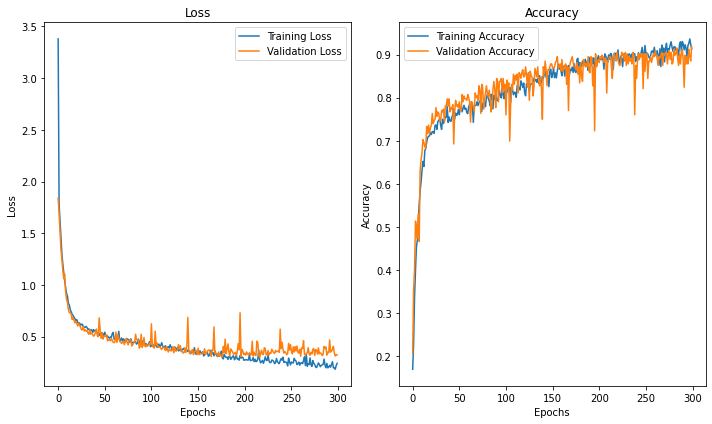

In [9]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):
    plt.figure(figsize=(10, 6))

    # Training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_learning_curve(training)

In [13]:
# Step 6 Model Evaluation

from tensorflow.keras.models import load_model

mlp_model = load_model('best_model_2.hdf5')
predictions = mlp_model.predict(X_test)
y_predict = np.argmax(predictions,axis=1)

class_names = {0:'Insufficient_Weight',
               1:'Normal_Weight',
               2:'Overweight_Level_I',
               3:'Overweight_Level_II',
               4:'Obesity_Type_I',
               5:'Obesity_Type_II',
               6:'Obesity_Type_III'
              }

predicted_class = [class_names[idx] for idx in y_predict]

20/20 [==============================] - 0s 526us/step


In [14]:
from sklearn.metrics import accuracy_score, classification_report

test_accuracy = accuracy_score(y_test,y_predict)
print("Test Accuracy: {}".format(test_accuracy))

Test Accuracy: 0.8943217665615142


In [15]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93        82
           1       0.90      0.70      0.78        86
           2       0.73      0.86      0.79        87
           3       0.85      0.76      0.80        87
           4       0.92      0.97      0.94       106
           5       1.00      0.97      0.98        89
           6       0.99      1.00      0.99        97

    accuracy                           0.89       634
   macro avg       0.90      0.89      0.89       634
weighted avg       0.90      0.89      0.89       634

